In [43]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline

In [44]:
df=pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [45]:
df.shape

(243, 15)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 28.6+ KB


In [47]:
df.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


In [48]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [49]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [50]:
df.isnull().sum()

day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Classes        0
Region         0
dtype: int64

In [51]:
df.drop(['day', 'month', 'year'],axis=1,inplace=True)

In [52]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [53]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [54]:
df['Classes']=np.where(df['Classes'].str.contains('not fire'),0,1)
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [55]:
df.tail()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
238,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,0,1
240,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,0,1
241,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,0,1
242,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,0,1


In [56]:
df['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

In [57]:
X=df.drop(['FWI'], axis=1)
X.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0,0


In [58]:
y=df['FWI']
y.tail()

238    6.5
239    0.0
240    0.2
241    0.7
242    0.5
Name: FWI, dtype: float64

In [59]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.25)

In [60]:
X_train.shape, X_test.shape

((182, 11), (61, 11))

In [61]:
#Selecting features based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.646041,-0.254168,-0.296530,0.659331,0.477542,0.387397,0.554840,0.456863,0.512832,0.224709
RH,-0.646041,1.000000,0.237848,0.205194,-0.658787,-0.394643,-0.243483,-0.636156,-0.350368,-0.455929,-0.371010
Ws,-0.254168,0.237848,1.000000,0.073402,-0.127764,0.011079,0.082261,0.064385,0.039865,-0.027015,-0.132973
Rain,-0.296530,0.205194,0.073402,1.000000,-0.542427,-0.291840,-0.292042,-0.359681,-0.300980,-0.350803,-0.004978
FFMC,0.659331,-0.658787,-0.127764,-0.542427,1.000000,0.597658,0.506060,0.750055,0.587827,0.752516,0.178130
DMC,0.477542,-0.394643,0.011079,-0.291840,0.597658,1.000000,0.882924,0.715739,0.982350,0.595027,0.146889
DC,0.387397,-0.243483,0.082261,-0.292042,0.506060,0.882924,1.000000,0.573531,0.944570,0.523518,-0.097318
ISI,0.554840,-0.636156,0.064385,-0.359681,0.750055,0.715739,0.573531,1.000000,0.694486,0.763515,0.188406
BUI,0.456863,-0.350368,0.039865,-0.300980,0.587827,0.982350,0.944570,0.694486,1.000000,0.600329,0.050320
Classes,0.512832,-0.455929,-0.027015,-0.350803,0.752516,0.595027,0.523518,0.763515,0.600329,1.000000,0.123849


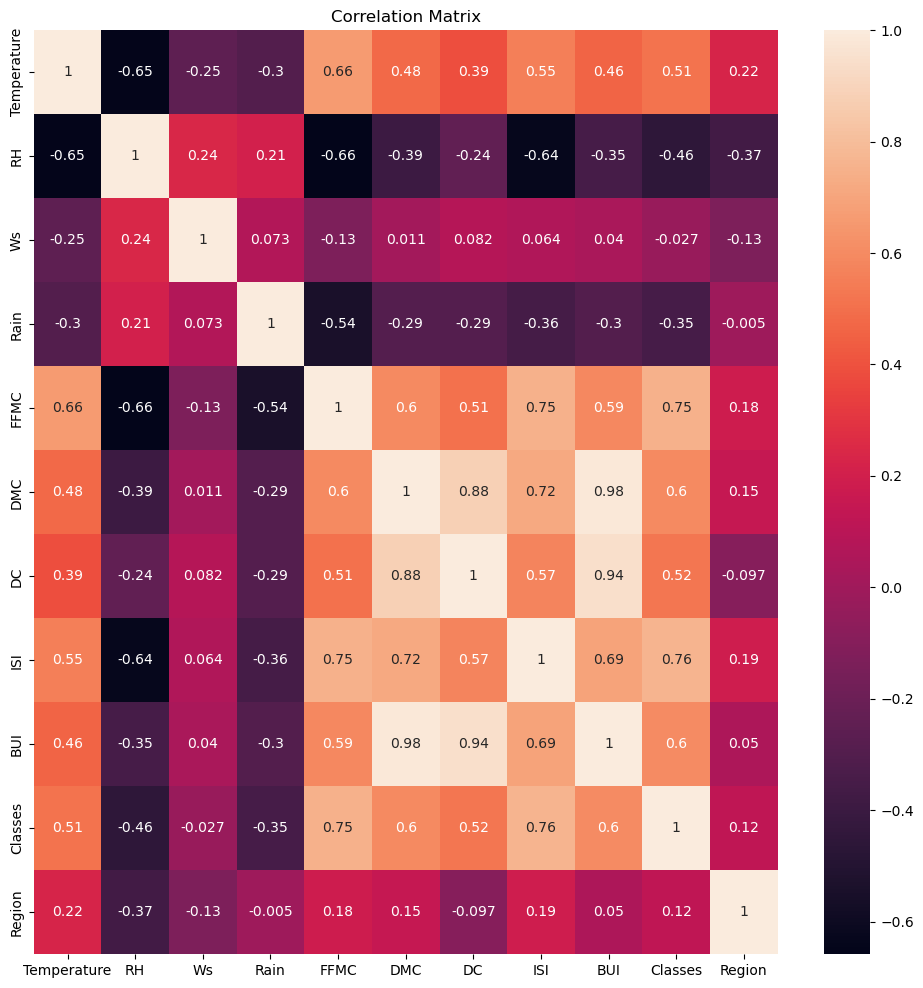

In [62]:
plt.figure(figsize=(12,12))
plt.title('Correlation Matrix')
sns.heatmap(X_train.corr(), annot=True)
plt.show()

In [63]:
#Determining multicollinearity and dropping those features 

In [64]:
X_train.shape

(182, 11)

In [65]:
X_test.shape

(61, 11)

In [66]:
def correlation(dataset, thresholds):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i): #checks only the lower triangle
            if abs(corr_matrix.iloc[i,j]) > thresholds:
                col_corr.add(corr_matrix.columns[i])
    return col_corr

In [67]:
correlated_features=correlation(X_train,0.85)
correlated_features

{'BUI', 'DC'}

In [68]:
X_train.drop(correlated_features, axis=1, inplace=True)
X_train.shape

(182, 9)

In [69]:
X_test.drop(correlated_features, axis=1, inplace=True)
X_test.shape

(61, 9)

Feature scaling Or Standardization

In [70]:
sc=StandardScaler()
X_train_scaled=sc.fit_transform(X_train)
X_test_scaled=sc.transform(X_test)

In [71]:
X_train_scaled[0:5]

array([[ 0.29559501,  0.35599947, -0.14556779, -0.40077958,  0.62711059,
         0.7827212 ,  0.248766  ,  0.9258201 ,  1.03352882],
       [-0.54064786, -1.53114336, -0.14556779, -0.40077958,  0.85464797,
        -0.07554056,  1.11840177,  0.9258201 ,  1.03352882],
       [ 1.41058551, -0.55262486, -0.14556779, -0.40077958,  0.84775289,
         1.13898081,  1.09122565,  0.9258201 ,  1.03352882],
       [ 1.13183788, -0.62251903, -0.50358588, -0.40077958,  0.96496912,
         4.18338103,  1.55321965,  0.9258201 ,  1.03352882],
       [ 0.57434263, -0.27304814,  0.21245029, -0.40077958,  0.76501203,
         0.4264616 ,  0.84664059,  0.9258201 ,  1.03352882]])

In [72]:
X_test_scaled[0:5]

array([[ 1.13183788, -0.0633656 ,  0.21245029, -0.40077958,  0.74432681,
         0.18355733,  0.73793612,  0.9258201 ,  1.03352882],
       [ 1.41058551, -1.60103754, -0.86160396, -0.40077958,  1.02702477,
         0.65317226,  1.77062859,  0.9258201 ,  1.03352882],
       [-0.54064786, -0.62251903, -0.50358588,  1.43163402, -0.44852065,
        -0.26176717, -0.81110259, -1.08012345,  1.03352882],
       [-0.81939549,  0.14631694,  1.28650455, -0.04611888, -0.60021223,
        -0.70709167, -0.75675035, -1.08012345, -0.96755889],
       [ 2.24682838, -2.23008515, -0.14556779, -0.40077958,  1.18561142,
         0.66936588,  3.34684341,  0.9258201 ,  1.03352882]])

In [73]:
#Box plot to check training data before and after scaling

<function matplotlib.pyplot.show(close=None, block=None)>

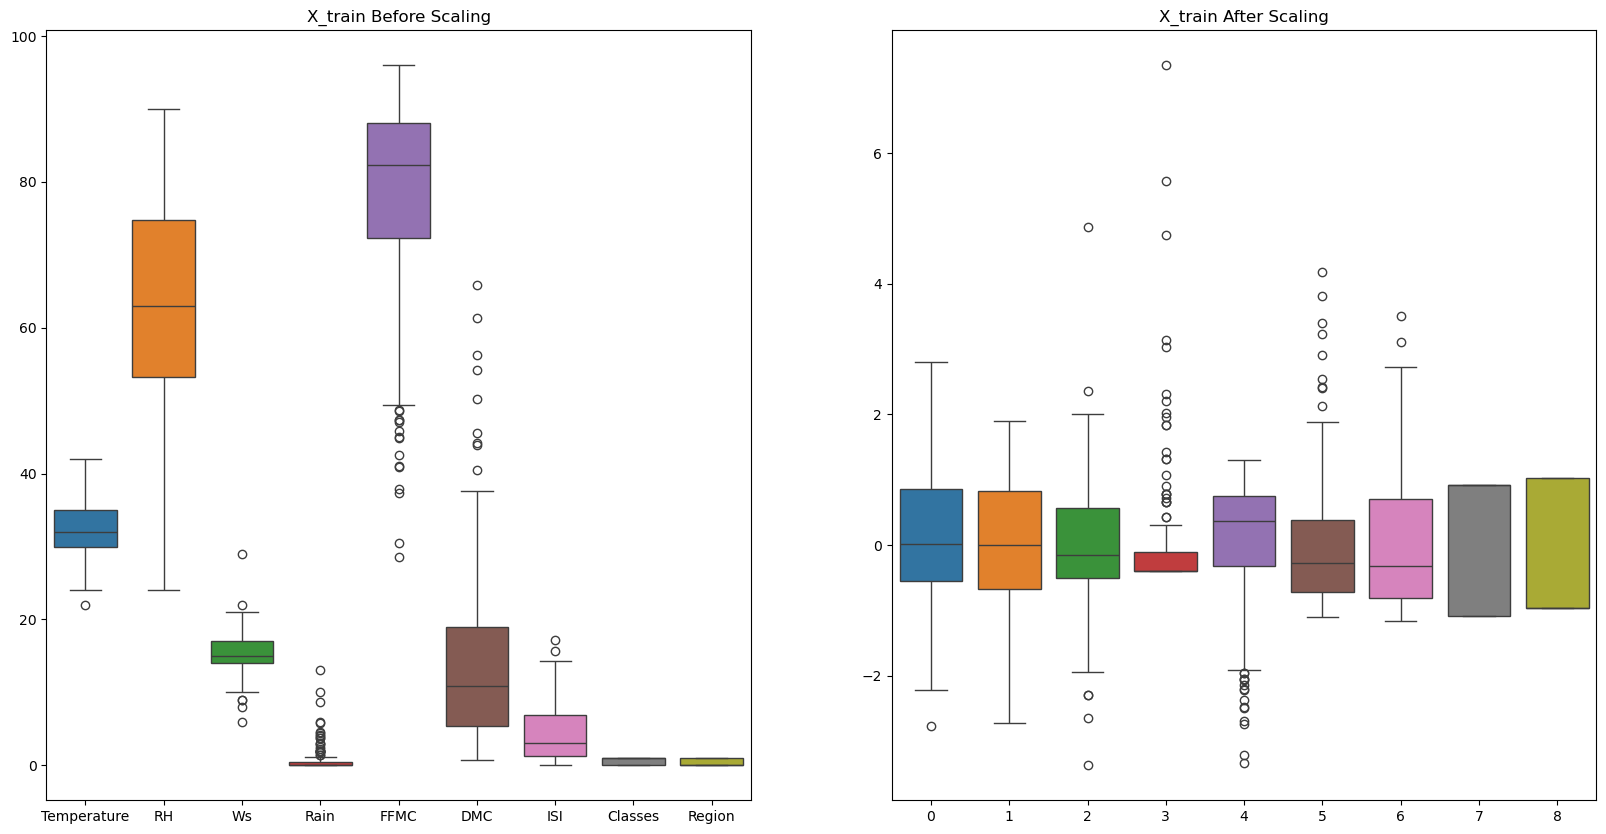

In [74]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
sns.boxplot(X_train)
plt.title('X_train Before Scaling')
plt.subplot(1,2,2)
sns.boxplot(X_train_scaled)
plt.title('X_train After Scaling')
plt.show

In [75]:
#Linear Regression

Mean Absolute error 0.89869432183143
R2 Score 0.9238973308259893


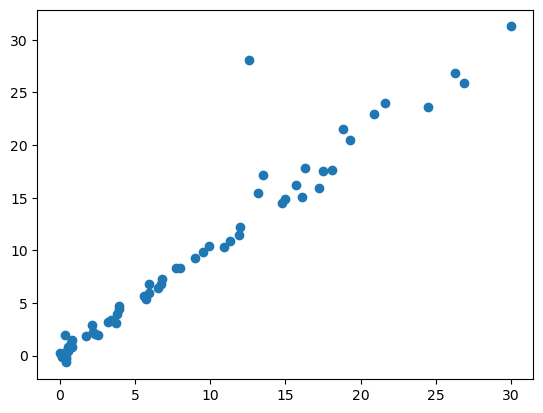

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
linear=LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred=linear.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute error {mae}')
print(f'R2 Score {score}')
plt.scatter(y_test,y_pred)

In [77]:
#Ridge Regression

Mean Absolute error 0.8835611897841356
R2 Score 0.9270488983808006


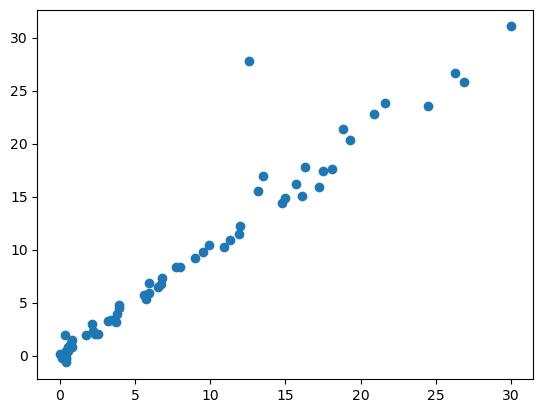

In [78]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
ridge=Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred=ridge.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute error {mae}')
print(f'R2 Score {score}')
plt.scatter(y_test,y_pred)

In [79]:
#Lasso Regression

Mean Absolute error 1.2544732629675042
R2 Score 0.936418889483245


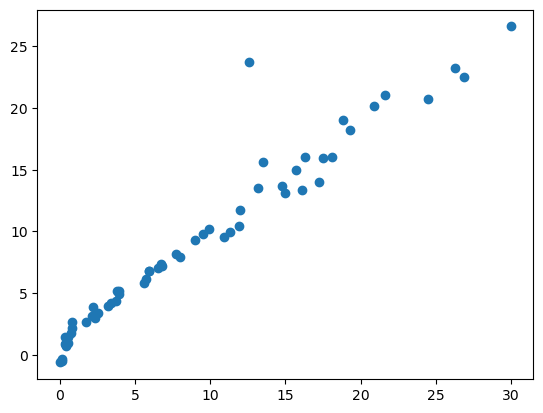

In [80]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, r2_score
lasso=Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred=lasso.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute error {mae}')
print(f'R2 Score {score}')
plt.scatter(y_test,y_pred)

In [82]:
#Cross validation Lasso - tries multiple alpha values automtically

In [84]:
from sklearn.linear_model import LassoCV
lassocv=LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [ ]:
#all alpha values

In [85]:
lassocv.alphas_

array([6.69376379, 6.24262651, 5.82189438, 5.42951818, 5.06358683,
       4.72231802, 4.40404959, 4.10723139, 3.83041774, 3.5722604 ,
       3.33150201, 3.10696992, 2.89757055, 2.70228399, 2.5201591 ,
       2.35030881, 2.19190586, 2.04417874, 1.90640794, 1.77792242,
       1.6580964 , 1.54634625, 1.44212769, 1.34493311, 1.25428912,
       1.16975423, 1.09091671, 1.01739258, 0.94882372, 0.88487618,
       0.82523849, 0.76962017, 0.71775035, 0.66937638, 0.62426265,
       0.58218944, 0.54295182, 0.50635868, 0.4722318 , 0.44040496,
       0.41072314, 0.38304177, 0.35722604, 0.3331502 , 0.31069699,
       0.28975705, 0.2702284 , 0.25201591, 0.23503088, 0.21919059,
       0.20441787, 0.19064079, 0.17779224, 0.16580964, 0.15463463,
       0.14421277, 0.13449331, 0.12542891, 0.11697542, 0.10909167,
       0.10173926, 0.09488237, 0.08848762, 0.08252385, 0.07696202,
       0.07177503, 0.06693764, 0.06242627, 0.05821894, 0.05429518,
       0.05063587, 0.04722318, 0.0440405 , 0.04107231, 0.03830

In [ ]:
# Best alpha value

In [86]:
lassocv.alpha_

np.float64(0.028975705498169156)

In [87]:
#MSE value for each validation fold

In [88]:
lassocv.mse_path_

array([[46.92790318, 32.80293091, 46.73536144, 57.32909131, 69.59802574],
       [41.3374584 , 28.55398733, 41.07313817, 51.87953774, 69.59802574],
       [36.50418641, 24.86538832, 36.05486498, 47.07903583, 63.47652444],
       [32.30670162, 21.66366595, 31.31449319, 42.84714086, 56.47865391],
       [28.05509419, 18.88500122, 27.20617216, 39.11361011, 50.37908327],
       [24.37259614, 16.47384802, 23.6467792 , 35.81709268, 44.31761248],
       [21.18382322, 14.38197842, 20.56377942, 32.90398865, 38.89890908],
       [18.42395522, 12.56747621, 17.89426086, 29.31427075, 34.17553752],
       [16.03600022, 10.99383896, 15.58343871, 25.93968653, 30.05733608],
       [13.97067776,  9.62941052, 13.58409545, 22.98595564, 26.46681434],
       [12.18497391,  8.44665541, 11.85483521, 20.39907328, 23.33551506],
       [10.64216194,  7.42164394, 10.35982784, 18.13246146, 20.60419311],
       [ 9.30971106,  6.53360277,  9.06795407, 16.14552838, 18.22128196],
       [ 8.15958714,  5.7644164 ,  7.9

In [94]:
lassocv.get_params()

{'alphas': 'warn',
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': False}

Mean Absolute Error 0.8996972055874654
r2_score 0.9261887082621443


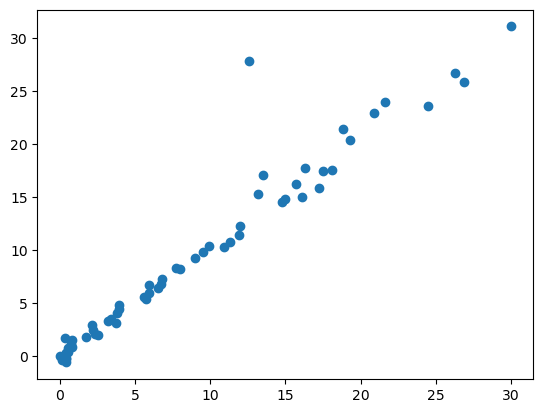

In [89]:
y_pred=lassocv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error {mae}')
print(f'r2_score {score}')
plt.scatter(y_test,y_pred)

In [90]:
#Cross validation Ridge - tries multiple alpha values automtically

Mean Absolute Error 0.8966810315069759
r2_score 0.9242309161443872


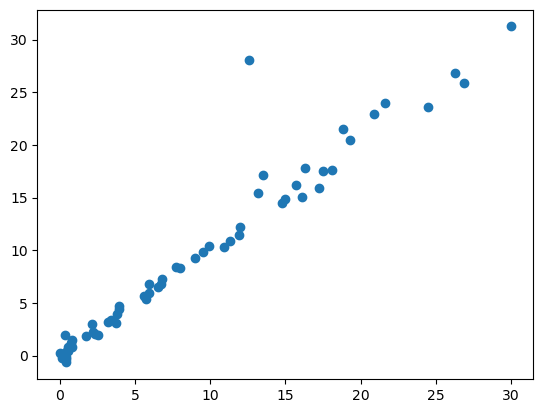

In [91]:
from sklearn.linear_model import RidgeCV
ridgecv=RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred=ridgecv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error {mae}')
print(f'r2_score {score}')
plt.scatter(y_test,y_pred)

In [92]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

In [93]:
ridgecv.alpha_

np.float64(0.1)

In [95]:
#ElasticNetCV Regression - balances both lasso and ridge, uses l1 ratio to balance both

Mean Absolute Error 0.8793405233326324
r2_score 0.9280434990955496


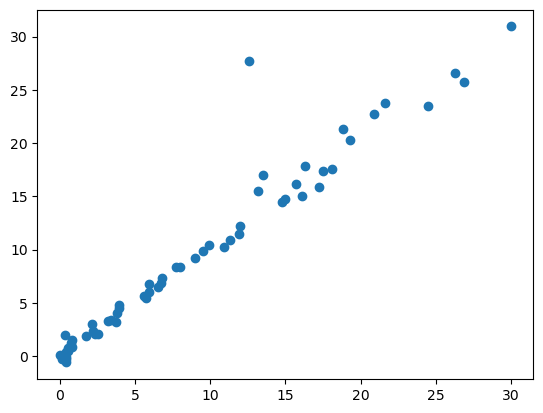

In [96]:
from sklearn.linear_model import ElasticNetCV
elasticcv=ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled, y_train)
y_pred=elasticcv.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(f'Mean Absolute Error {mae}')
print(f'r2_score {score}')
plt.scatter(y_test,y_pred)

In [97]:
elasticcv.get_params()

{'alphas': 'warn',
 'copy_X': True,
 'cv': 5,
 'eps': 0.001,
 'fit_intercept': True,
 'l1_ratio': 0.5,
 'max_iter': 1000,
 'n_alphas': 'deprecated',
 'n_jobs': None,
 'positive': False,
 'precompute': 'auto',
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'verbose': 0}

In [98]:
elasticcv.alpha_

np.float64(0.0133875275704367)

In [99]:
elasticcv.l1_ratio_

np.float64(0.5)